### Assignment-03

- Using the provided ```U-Net``` training notebook as a reference, develop and train a ```DeepLabv3+``` model on the sample dataset available in the ```data``` folder (accessible through the provided Google Drive shortcut).

- For model evaluation, use the same test image that was previously used to evaluate the U-Net model. Save and upload the output image generated by your trained DeepLabv3+ model to the ```data/output``` folder.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE"

IMAGE_PATH = os.path.join("/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE"
, "train2017")
MASK_PATH  = os.path.join("/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE"
,"mask_train2017")
TEST_PATH  = os.path.join("/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE"
, "test2017")
OUTPUT_PATH = os.path.join("/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE"
, "output")

os.makedirs(OUTPUT_PATH, exist_ok=True)

IMG_SIZE = 256


In [ ]:
print("Image path exists:", os.path.exists(IMAGE_PATH))
print("Mask path exists:", os.path.exists(MASK_PATH))

print("Sample images:", os.listdir(IMAGE_PATH)[:5])
print("Sample masks:", os.listdir(MASK_PATH)[:5])


Image path exists: True
Mask path exists: True
Sample images: ['000000532933.jpg', '000000532989.jpg', '000000532735.jpg', '000000532732.jpg', '000000532976.jpg']
Sample masks: ['000000182715_mask.png', '000000182723_mask.png', '000000182728_mask.png', '000000182734_mask.png', '000000182736_mask.png']


In [ ]:
def load_data(image_dir, mask_dir, limit=30):
    images = []
    masks = []

    image_files = sorted(os.listdir(image_dir))

    count = 0
    for img_file in image_files:
        img_id = os.path.splitext(img_file)[0]

        # IMPORTANT FIX: mask filename pattern
        mask_file = img_id + "_mask.png"
        mask_path = os.path.join(mask_dir, mask_file)

        if not os.path.exists(mask_path):
            continue

        img_path = os.path.join(image_dir, img_file)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        if img is None or mask is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

        count += 1
        if count >= limit:
            break

    return np.array(images), np.array(masks)


In [ ]:
X, Y = load_data(IMAGE_PATH, MASK_PATH)

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)


Images shape: (30, 256, 256, 3)
Masks shape: (30, 256, 256, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [ ]:
def aspp_block(x):
    y1 = layers.Conv2D(256, 1, padding="same", activation="relu")(x)
    y2 = layers.Conv2D(256, 3, dilation_rate=6, padding="same", activation="relu")(x)
    y3 = layers.Conv2D(256, 3, dilation_rate=12, padding="same", activation="relu")(x)
    y4 = layers.Conv2D(256, 3, dilation_rate=18, padding="same", activation="relu")(x)

    y = layers.Concatenate()([y1, y2, y3, y4])
    y = layers.Conv2D(256, 1, padding="same", activation="relu")(y)

    return y


In [ ]:
def DeepLabV3Plus():
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    x = base_model.get_layer("block_13_expand_relu").output
    x = aspp_block(x)

    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)
    output = layers.Conv2D(1, 1, activation="sigmoid")(x)

    model = models.Model(inputs=base_model.input, outputs=output)
    return model


In [ ]:
model = DeepLabV3Plus()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/tmp/ipython-input-467487149.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 5,303,617 (20.23 MB)

 Trainable params: 5,286,337 (20.17 MB)

 Non-trainable params: 17,280 (67.50 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=4
)


Epoch 1/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 77s 4s/step - accuracy: 0.4817 - loss: 1.2378 - val_accuracy: 0.6809 - val_loss: 0.5568
Epoch 2/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.7283 - loss: 0.5587 - val_accuracy: 0.7064 - val_loss: 0.5101
Epoch 3/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.7413 - loss: 0.5116 - val_accuracy: 0.7445 - val_loss: 0.6523
Epoch 4/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.8716 - loss: 0.3232 - val_accuracy: 0.7366 - val_loss: 1.2852
Epoch 5/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.8700 - loss: 0.2889 - val_accuracy: 0.7517 - val_loss: 0.8848
Epoch 6/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8640 - loss: 0.2849 - val_accuracy: 0.7534 - val_loss: 0.8036
Epoch 7/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9054 - loss: 0.2236 - val_accuracy: 0.7094 - val_loss: 1.1656
Epoch 8/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9151 - loss: 0.1971 - val_accuracy: 0.7032 - val_loss: 1.1979


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train images:", X_train.shape)
print("Validation images:", X_val.shape)


Train images: (24, 256, 256, 3)
Validation images: (6, 256, 256, 3)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=4
)


Epoch 1/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9484 - loss: 0.1219 - val_accuracy: 0.7002 - val_loss: 1.3504
Epoch 2/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9259 - loss: 0.1757 - val_accuracy: 0.7174 - val_loss: 1.2582
Epoch 3/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9503 - loss: 0.1139 - val_accuracy: 0.7199 - val_loss: 1.2605
Epoch 4/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9422 - loss: 0.1291 - val_accuracy: 0.7320 - val_loss: 1.2082
Epoch 5/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.9097 - loss: 0.2089 - val_accuracy: 0.7490 - val_loss: 1.0870
Epoch 6/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9339 - loss: 0.1473 - val_accuracy: 0.7440 - val_loss: 0.9331
Epoch 7/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9330 - loss: 0.1468 - val_accuracy: 0.7412 - val_loss: 1.1870
Epoch 8/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9378 - loss: 0.1428 - val_accuracy: 0.7443 - val_loss: 1.0946


In [ ]:
import cv2
import numpy as np
import os

test_image_name = os.listdir(TEST_PATH)[0]

test_img = cv2.imread(os.path.join(TEST_PATH, test_image_name))
test_img = cv2.resize(test_img, (IMG_SIZE, IMG_SIZE))
test_img = test_img / 255.0

test_input = np.expand_dims(test_img, axis=0)

print("Test image loaded:", test_image_name)


Test image loaded: 000000436731.jpg


In [ ]:
pred_mask = model.predict(test_input)[0]
pred_mask = (pred_mask > 0.5).astype(np.uint8) * 255

output_file = os.path.join(OUTPUT_PATH, "deeplabv3plus_output.png")
cv2.imwrite(output_file, pred_mask)

print("Output image saved at:")
print(output_file)


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Output image saved at:
/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/output/deeplabv3plus_output.png


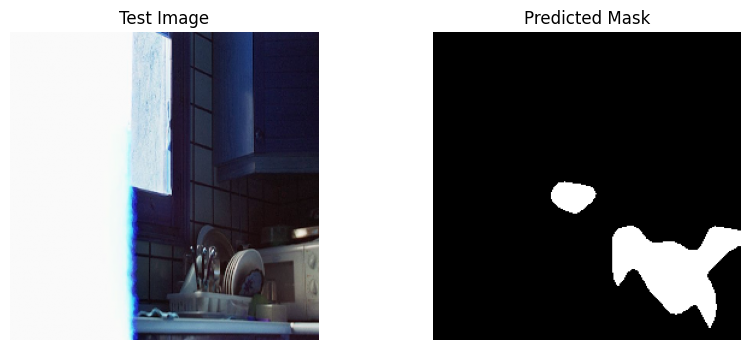

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Test Image")
plt.imshow(test_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()
